In [2]:
import pandas as pd

In [23]:
df_products = pd.read_csv("../data/raw/amazon_products.csv")
df_categories = pd.read_csv("../data/raw/amazon_categories.csv")
print("Products:", df_products.shape)
print("Categories:", df_products.shape)

Products: (1426337, 11)
Categories: (1426337, 11)


In [24]:
print(df_products.columns.tolist())

['asin', 'title', 'imgUrl', 'productURL', 'stars', 'reviews', 'price', 'listPrice', 'category_id', 'isBestSeller', 'boughtInLastMonth']


In [25]:
df_products.head()

,asin,title,imgUrl,productURL,stars,reviews,price,listPrice,category_id,isBestSeller,boughtInLastMonth
0,B014TMV5YE,"Sion Softside Expandable Roller Luggage, Black...",https://m.media-amazon.com/images/I/815dLQKYIY...,https://www.amazon.com/dp/B014TMV5YE,4.5,0,139.99,0.00,104,False,2000
1,B07GDLCQXV,Luggage Sets Expandable PC+ABS Durable Suitcas...,https://m.media-amazon.com/images/I/81bQlm7vf6...,https://www.amazon.com/dp/B07GDLCQXV,4.5,0,169.99,209.99,104,False,1000
2,B07XSCCZYG,Platinum Elite Softside Expandable Checked Lug...,https://m.media-amazon.com/images/I/71EA35zvJB...,https://www.amazon.com/dp/B07XSCCZYG,4.6,0,365.49,429.99,104,False,300
3,B08MVFKGJM,Freeform Hardside Expandable with Double Spinn...,https://m.media-amazon.com/images/I/91k6NYLQyI...,https://www.amazon.com/dp/B08MVFKGJM,4.6,0,291.59,354.37,104,False,400
4,B01DJLKZBA,Winfield 2 Hardside Expandable Luggage with Sp...,https://m.media-amazon.com/images/I/61NJoaZcP9...,https://www.amazon.com/dp/B01DJLKZBA,4.5,0,174.99,309.99,104,False,400


In [26]:
df_products.isnull().sum()

asin                 0
title                1
imgUrl               0
productURL           0
stars                0
reviews              0
price                0
listPrice            0
category_id          0
isBestSeller         0
boughtInLastMonth    0
dtype: int64

In [27]:
df_products.dtypes

asin                  object
title                 object
imgUrl                object
productURL            object
stars                float64
reviews                int64
price                float64
listPrice            float64
category_id            int64
isBestSeller            bool
boughtInLastMonth      int64
dtype: object

In [28]:
df_products[["stars","reviews","price","listPrice"]].describe()

,stars,reviews,price,listPrice
count,1.426337e+06,1.426337e+06,1.426337e+06,1.426337e+06
mean,3.999512e+00,1.807508e+02,4.337540e+01,1.244916e+01
std,1.344292e+00,1.761453e+03,1.302893e+02,4.611198e+01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,4.100000e+00,0.000000e+00,1.199000e+01,0.000000e+00
50%,4.400000e+00,0.000000e+00,1.995000e+01,0.000000e+00
75%,4.600000e+00,0.000000e+00,3.599000e+01,0.000000e+00
max,5.000000e+00,3.465630e+05,1.973181e+04,9.999900e+02


In [29]:
print("unique categories:", df_products["category_id"].nunique())
print("Best sellers:", df_products["isBestSeller"].sum())

unique categories: 248
Best sellers: 8520


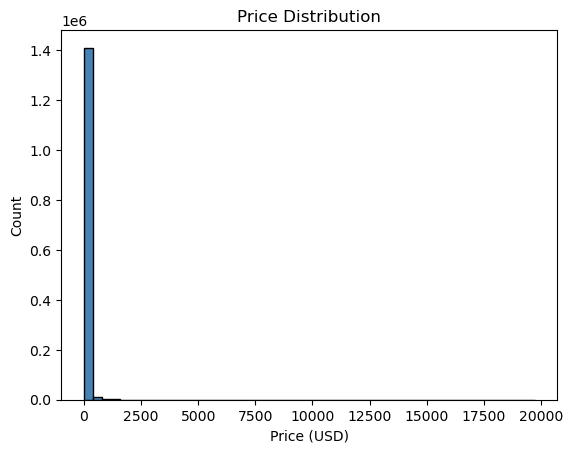

In [30]:
import matplotlib.pyplot as plt

df_products["price"].dropna().plot(kind="hist", bins=50, color="steelblue", edgecolor="black")
plt.title("Price Distribution")
plt.xlabel("Price (USD)")
plt.ylabel("Count")
plt.show()

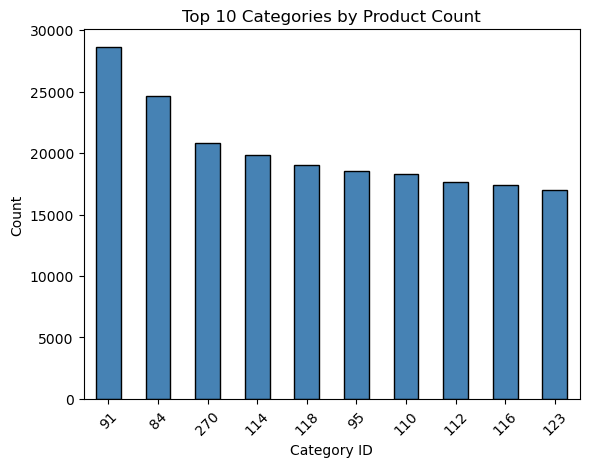

In [31]:
top_categories = df_products["category_id"].value_counts().head(10)
top_categories.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Top 10 Categories by Product Count")
plt.xlabel("Category ID")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [32]:
df_categories.head(10)

,id,category_name
0,1,Beading & Jewelry Making
1,2,Fabric Decorating
2,3,Knitting & Crochet Supplies
3,4,Printmaking Supplies
4,5,Scrapbooking & Stamping Supplies
5,6,Sewing Products
6,7,Craft & Hobby Fabric
7,8,Needlework Supplies
8,9,"Arts, Crafts & Sewing Storage"
9,10,"Painting, Drawing & Art Supplies"


In [33]:
df_merged = df_products.merge(df_categories, left_on="category_id", right_on="id", how="left")
df_merged[["title", "price", "stars", "category_name"]].head(10)

,title,price,stars,category_name
0,"Sion Softside Expandable Roller Luggage, Black...",139.99,4.5,Suitcases
1,Luggage Sets Expandable PC+ABS Durable Suitcas...,169.99,4.5,Suitcases
2,Platinum Elite Softside Expandable Checked Lug...,365.49,4.6,Suitcases
3,Freeform Hardside Expandable with Double Spinn...,291.59,4.6,Suitcases
4,Winfield 2 Hardside Expandable Luggage with Sp...,174.99,4.5,Suitcases
5,Maxlite 5 Softside Expandable Luggage with 4 S...,144.49,4.5,Suitcases
6,"Hard Shell Carry on Luggage Airline Approved, ...",169.99,4.5,Suitcases
7,"Maxporter II 30"" Hardside Spinner Trunk Luggag...",299.99,4.5,Suitcases
8,Omni 2 Hardside Expandable Luggage with Spinne...,112.63,4.5,Suitcases
9,Luggage Sets Expandable Lightweight Suitcases ...,209.99,4.4,Suitcases


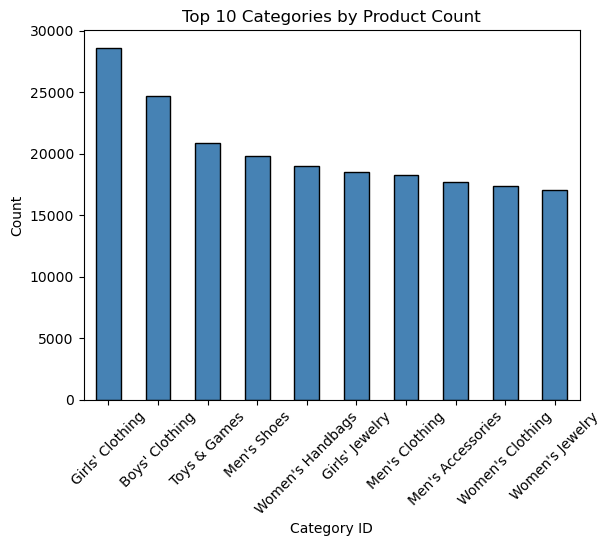

In [35]:
top_categories = df_merged["category_name"].value_counts().head(10)
top_categories.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Top 10 Categories by Product Count")
plt.xlabel("Category ID")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [36]:
print("=== DATASET SUMMARY ===")
print(f"Total products: {len(df_products):,}")
print(f"Products with price: {df_products['price'].notna().sum():,}")
print(f"Products without price: {df_products['price'].isna().sum():,}")
print(f"Average price: ${df_products['price'].mean():.2f}")
print(f"Average rating: {df_products['stars'].mean():.2f}")
print(f"Total categories: {df_products['category_id'].nunique()}")
print(f"Best sellers: {df_products['isBestSeller'].sum():,}")

=== DATASET SUMMARY ===
Total products: 1,426,337
Products with price: 1,426,337
Products without price: 0
Average price: $43.38
Average rating: 4.00
Total categories: 248
Best sellers: 8,520
